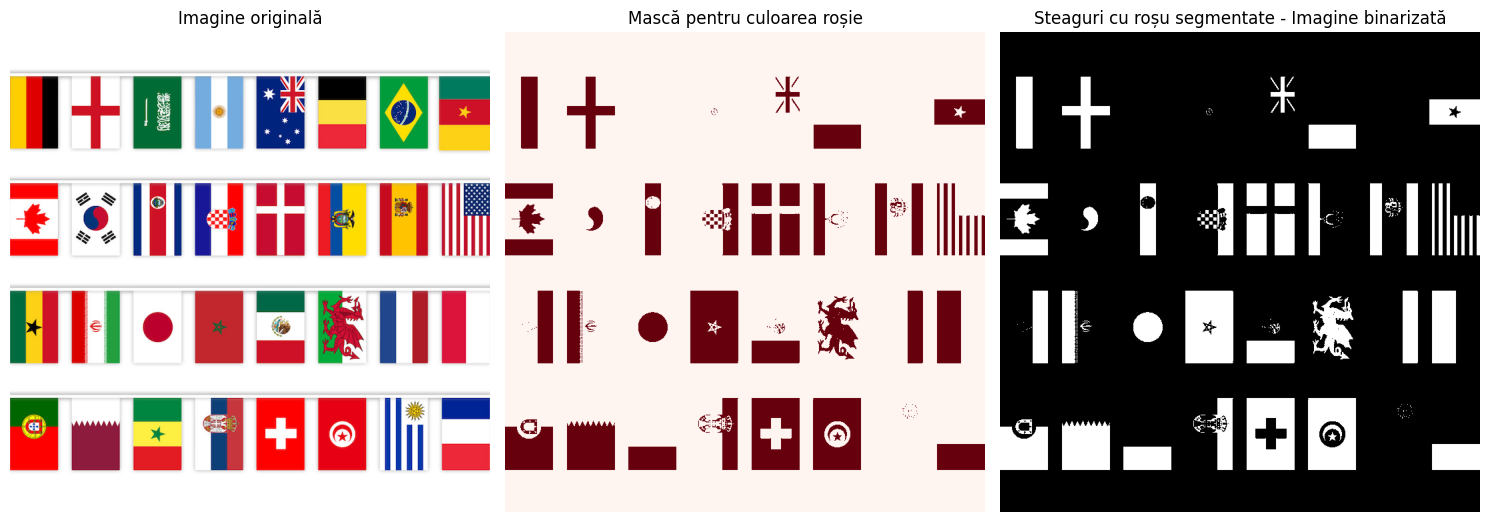

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, measure
from sklearn.cluster import KMeans


# Funcție pentru segmentarea steagurilor care au culoarea roșie

def segment_flags_with_red(image_path, n_clusters=5):
    # Încărcăm imaginea
    img = io.imread(image_path)

    # Reshape pentru clustering
    H, W, C = img.shape
    data = img.reshape((-1, 3))  # Transformăm imaginea în vectori de culoare (R, G, B)

    # Aplicăm KMeans pentru a clasifica pixelii în funcție de culoare
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(data)
    labels = kmeans.labels_.reshape((H, W))
    centers = kmeans.cluster_centers_

    # Identificăm clusterul care corespunde culorii roșii
    red_cluster = np.argmax(centers[:, 0] - (centers[:, 1] + centers[:, 2]) / 2)

    # Creăm masca pentru culoarea roșie
    red_mask = (labels == red_cluster)

    # Binarizăm imaginea pentru regiunile cu roșu
    binary_mask = red_mask.astype(np.uint8)

    # Afișăm rezultatele
    plt.figure(figsize=(15, 10))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Imagine originală")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(red_mask, cmap="Reds")
    plt.title("Mască pentru culoarea roșie")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(binary_mask, cmap="gray")
    plt.title("Steaguri cu roșu segmentate - Imagine binarizată")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# Apelăm funcția pentru imaginea 'steaguri.png'
segment_flags_with_red('steaguri.png')